In [ ]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [ ]:
spark = SparkSession.builder.getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = spark.read.csv('/content/drive/MyDrive/ProjetoAnaliseSalariosDados/global_ai_jobs.csv', header=True, inferSchema=True)

In [ ]:
df.head()

Row(id=1, country='UAE', job_role='Machine Learning Engineer', ai_specialization='Reinforcement Learning', experience_level='Entry', experience_years=0, salary_usd=66465, bonus_usd=5395, education_required='Master', industry='Automotive', company_size='Small', interview_rounds=7, year=2020, work_mode='Remote', weekly_hours=44.7, company_rating=3.67, job_openings=10, hiring_difficulty_score=52.76535075509017, layoff_risk=0.404, ai_adoption_score=91, company_funding_billion=3.3, economic_index=78.65, ai_maturity_years=13, offer_acceptance_rate=60.58, tax_rate_percent=20.8, vacation_days=27, skill_demand_score=12, automation_risk=76, job_security_score=57, career_growth_score=65, work_life_balance_score=73, promotion_speed=15, salary_percentile=55, cost_of_living_index=1.23, employee_satisfaction=76)

In [ ]:
df_filtrado = df['country', 'job_role', 'experience_level', 'experience_years', 'salary_usd', 'bonus_usd', 'education_required', 'industry', 'company_size', 'year', 'work_mode', 'weekly_hours', 'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score', 'offer_acceptance_rate', 'vacation_days', 'skill_demand_score', 'automation_risk', 'job_security_score', 'career_growth_score', 'work_life_balance_score', 'promotion_speed', 'cost_of_living_index', 'employee_satisfaction']

In [ ]:
df_filtrado.printSchema()

root
 |-- country: string (nullable = true)
 |-- job_role: string (nullable = true)
 |-- experience_level: string (nullable = true)
 |-- experience_years: integer (nullable = true)
 |-- salary_usd: integer (nullable = true)
 |-- bonus_usd: integer (nullable = true)
 |-- education_required: string (nullable = true)
 |-- industry: string (nullable = true)
 |-- company_size: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- work_mode: string (nullable = true)
 |-- weekly_hours: double (nullable = true)
 |-- hiring_difficulty_score: double (nullable = true)
 |-- layoff_risk: double (nullable = true)
 |-- ai_adoption_score: integer (nullable = true)
 |-- offer_acceptance_rate: double (nullable = true)
 |-- vacation_days: integer (nullable = true)
 |-- skill_demand_score: integer (nullable = true)
 |-- automation_risk: integer (nullable = true)
 |-- job_security_score: integer (nullable = true)
 |-- career_growth_score: integer (nullable = true)
 |-- work_life_balance_score:

In [ ]:
df_filtrado = df_filtrado.withColumn('date', expr("make_date(year, 1,1)"))

df_filtrado.printSchema()

root
 |-- country: string (nullable = true)
 |-- job_role: string (nullable = true)
 |-- experience_level: string (nullable = true)
 |-- experience_years: integer (nullable = true)
 |-- salary_usd: integer (nullable = true)
 |-- bonus_usd: integer (nullable = true)
 |-- education_required: string (nullable = true)
 |-- industry: string (nullable = true)
 |-- company_size: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- work_mode: string (nullable = true)
 |-- weekly_hours: double (nullable = true)
 |-- hiring_difficulty_score: double (nullable = true)
 |-- layoff_risk: double (nullable = true)
 |-- ai_adoption_score: integer (nullable = true)
 |-- offer_acceptance_rate: double (nullable = true)
 |-- vacation_days: integer (nullable = true)
 |-- skill_demand_score: integer (nullable = true)
 |-- automation_risk: integer (nullable = true)
 |-- job_security_score: integer (nullable = true)
 |-- career_growth_score: integer (nullable = true)
 |-- work_life_balance_score:

In [ ]:
df_filtrado.select('work_mode').distinct().show()

df_filtrado = df_filtrado.withColumn('work_mode_encoded', when(df_filtrado.work_mode == 'Hybrid', 1)\
                                     .when(df_filtrado.work_mode == 'Remote', 2)\
                                     .when(df_filtrado.work_mode == 'On-site', 0))

+---------+
|work_mode|
+---------+
|   Remote|
|   Onsite|
|   Hybrid|
+---------+



In [ ]:
df_filtrado.createOrReplaceGlobalTempView('tabela_temp')

query = spark.sql("""
  SELECT
    job_role,
    ROUND(AVG(salary_usd) , 2) AS avg_salary,
    ROUND(AVG(bonus_usd) ,2) AS avg_bonus,
    ROUND(AVG(experience_years) ,2) AS avg_experience_years,
    ROUND(AVG(promotion_speed), 2) AS avg_promotion_speed
  FROM
    global_temp.tabela_temp
  GROUP BY
    job_role
  ORDER BY
    avg_salary DESC
""")

df_jobxsalary = query.toPandas()
query.show()

+--------------------+----------+---------+--------------------+-------------------+
|            job_role|avg_salary|avg_bonus|avg_experience_years|avg_promotion_speed|
+--------------------+----------+---------+--------------------+-------------------+
|  Research Scientist|  109797.5| 14770.48|                7.01|              38.15|
|Machine Learning ...|  102121.8|  13755.6|                6.99|              38.34|
|Computer Vision E...| 101303.94| 13649.66|                 7.0|              38.55|
|        NLP Engineer|  99745.32| 13508.87|                7.06|              38.64|
|         AI Engineer|  97974.71| 13211.36|                7.07|              38.43|
|Software Engineer AI|  97375.53| 13196.87|                7.12|              38.72|
|      Data Scientist|   94029.9| 12660.66|                7.04|              38.47|
|        Data Analyst|  69429.27|   9393.2|                6.93|              38.22|
+--------------------+----------+---------+--------------------+-

In [ ]:
query = spark.sql("""
  SELECT
    job_role,
    ROUND(AVG(layoff_risk) , 2) AS avg_layoff_risk,
    ROUND(AVG(automation_risk) ,2) AS avg_automation_risk
  FROM
    global_temp.tabela_temp
  GROUP BY
    job_role
  ORDER BY
    avg_layoff_risk DESC
""")

df_jobxrisk = query.toPandas()
query.show()

+--------------------+---------------+-------------------+
|            job_role|avg_layoff_risk|avg_automation_risk|
+--------------------+---------------+-------------------+
|Machine Learning ...|           0.18|              50.15|
|  Research Scientist|           0.18|              50.61|
|Software Engineer AI|           0.18|              50.62|
|      Data Scientist|           0.18|              50.22|
|        Data Analyst|           0.18|              50.34|
|Computer Vision E...|           0.18|              50.64|
|        NLP Engineer|           0.18|              50.18|
|         AI Engineer|           0.18|              50.09|
+--------------------+---------------+-------------------+



In [ ]:
query = spark.sql("""
  SELECT
    country,
    ROUND(AVG(salary_usd) , 2) AS avg_salary,
    ROUND(AVG(hiring_difficulty_score) ,2) AS avg_hiring_difficulty_score,
    ROUND(AVG(cost_of_living_index) ,2) AS avg_cost_of_living_index,
    ROUND(AVG(salary_usd) / AVG(cost_of_living_index) ,2) AS real_salary
  FROM
    global_temp.tabela_temp
  GROUP BY
    country
  ORDER BY
    avg_salary DESC
""")

df_countryxsalary = query.toPandas()
query.show()

+-----------+----------+---------------------------+------------------------+-----------+
|    country|avg_salary|avg_hiring_difficulty_score|avg_cost_of_living_index|real_salary|
+-----------+----------+---------------------------+------------------------+-----------+
|        USA| 132995.21|                      54.94|                     1.5|   88533.23|
|  Singapore| 116954.73|                      55.26|                     1.5|   77956.66|
|  Australia| 110549.81|                      55.03|                    1.51|   73064.45|
|     Canada| 108671.05|                      55.02|                    1.51|   72098.98|
|         UK| 102826.24|                      54.96|                    1.51|   68080.08|
|Netherlands| 102379.05|                      54.81|                     1.5|   68239.62|
|    Germany| 100007.78|                      54.82|                     1.5|   66555.71|
|      Japan|  98507.66|                      55.18|                    1.51|   65284.03|
|     Fran

In [ ]:
query = spark.sql("""
  SELECT
    work_mode,
    ROUND(AVG(salary_usd) , 2) AS avg_salary,
    ROUND(AVG(employee_satisfaction), 2) AS avg_employee_satisfaction
  FROM
    global_temp.tabela_temp
  GROUP BY
    work_mode
  ORDER BY
    avg_salary DESC
""")

df_work_modexsalary = query.toPandas()
query.show()

+---------+----------+-------------------------+
|work_mode|avg_salary|avg_employee_satisfaction|
+---------+----------+-------------------------+
|   Hybrid|  96747.54|                    72.74|
|   Onsite|  96450.88|                    72.73|
|   Remote|  96442.69|                    72.72|
+---------+----------+-------------------------+



In [ ]:
query = spark.sql("""
  SELECT
    country,
    ROUND(AVG(employee_satisfaction) , 2) AS avg_employee_satisfaction,
    ROUND(AVG(work_life_balance_score) ,2) AS avg_work_life_balance_score,
    ROUND(AVG(vacation_days) ,2) AS avg_vacation_days,
    ROUND(AVG(salary_usd) / AVG(cost_of_living_index) ,2) AS real_salary
  FROM
    global_temp.tabela_temp
  GROUP BY
    country
  ORDER BY
    avg_employee_satisfaction DESC
""")

df_countryxsatisfaction = query.toPandas()
query.show()

+-----------+-------------------------+---------------------------+-----------------+-----------+
|    country|avg_employee_satisfaction|avg_work_life_balance_score|avg_vacation_days|real_salary|
+-----------+-------------------------+---------------------------+-----------------+-----------+
|        USA|                    76.29|                      68.96|            20.04|   88533.23|
|  Singapore|                    74.89|                      69.53|            19.95|   77956.66|
|  Australia|                    74.11|                      68.98|            20.02|   73064.45|
|     Canada|                    73.84|                      69.02|            19.98|   72098.98|
|Netherlands|                    73.46|                       69.4|             19.9|   68239.62|
|         UK|                    73.37|                      68.96|            20.07|   68080.08|
|    Germany|                    73.09|                      69.21|            19.94|   66555.71|
|      Japan|       

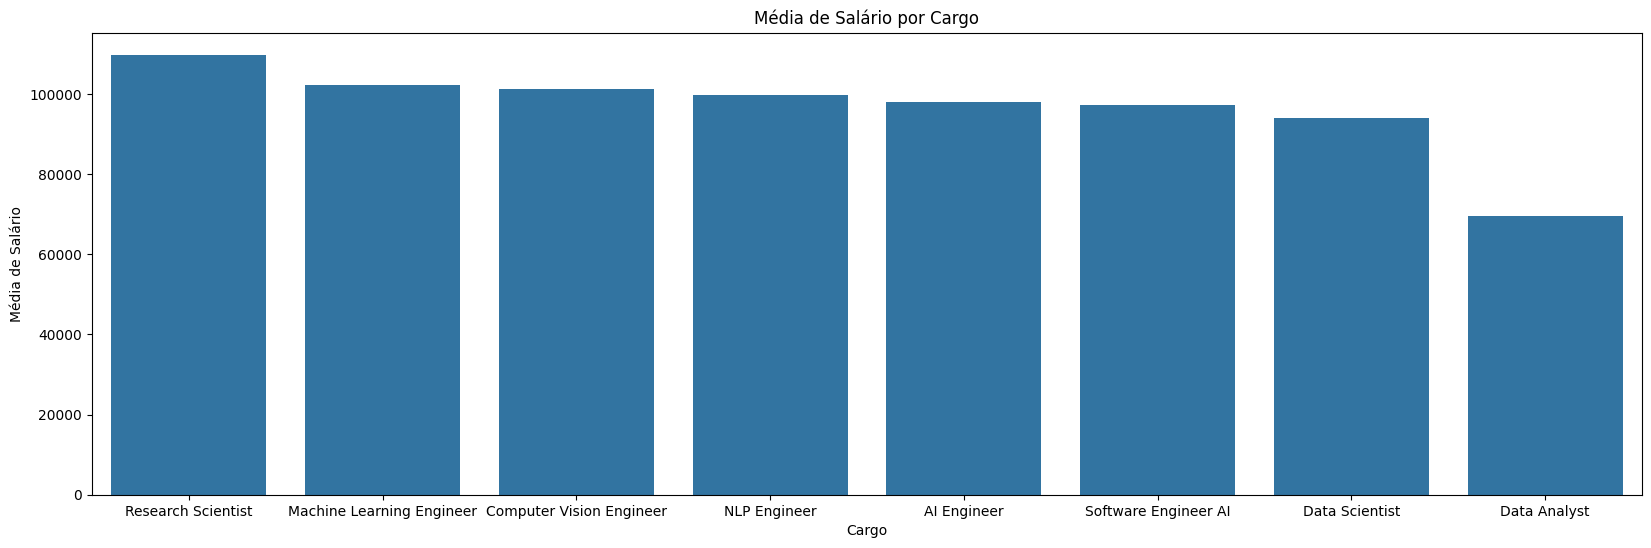

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Barra job x salary
plt.figure(figsize=(20, 6))
sns.barplot(data=df_jobxsalary, x='job_role', y='avg_salary')
plt.title('Média de Salário por Cargo')
plt.xlabel('Cargo')
plt.ylabel('Média de Salário')
plt.show()

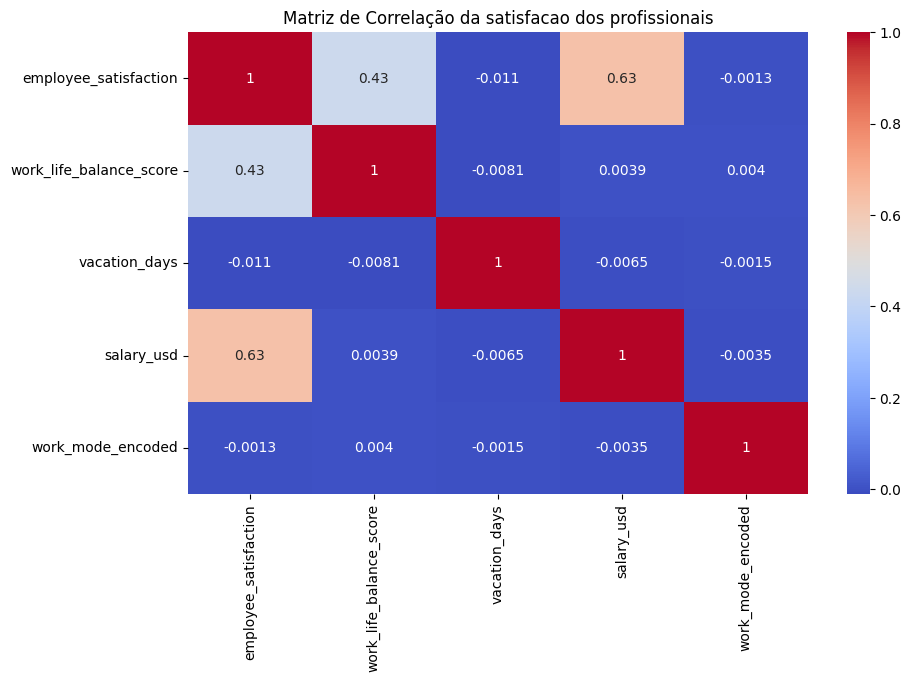

In [ ]:
# Correlacao da satisfacao dos profissionais

df_corr_spark = df_filtrado[['employee_satisfaction', 'work_life_balance_score', 'vacation_days', 'salary_usd', 'work_mode_encoded']]
df_corr_pandas = df_corr_spark.toPandas()

plt.figure(figsize=(10, 6))
sns.heatmap(df_corr_pandas.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação da satisfacao dos profissionais')
plt.show()

O salário real tem ligacão forte com a satisfacão dos profissionais



In [ ]:
df_filtrado.write.mode('overwrite').parquet('/content/drive/MyDrive/ProjetoAnaliseSalariosDados/df_ai_jobs_parquet')

In [ ]:
spark.stop()